# FPGA Speaker Recognition — FINN Synthesis Convolutional Neural Network

### Channel strategy

The MFCC dataset has 2 channels (I and Q from IQ radio data).
Both variants support a `USE_CHANNELS` config:
- `'I'` — use only the I channel (safest, matches KWS example)
- `'IQ'` — use both channels (more signal info, slightly higher risk)


---
## 1. Environment Setup

In [1]:
import torch
import numpy as np
import onnx

import os, json, pickle, copy, time, subprocess
from pathlib import Path

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import brevitas.nn as qnn
import brevitas.config as brev_cfg
brev_cfg.IGNORE_MISSING_KEYS = True

from brevitas.quant import (
    Int8ActPerTensorFloat, Int8WeightPerTensorFloat, Uint8ActPerTensorFloat,
)
from brevitas.export import export_qonnx

# Custom quantizers
class Int4WeightPerTensorFloat(Int8WeightPerTensorFloat):
    bit_width = 4

class Int4ActPerTensorFloat(Int8ActPerTensorFloat):
    bit_width = 4

class Uint4ActPerTensorFloat(Uint8ActPerTensorFloat):
    bit_width = 4

import librosa, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

RANDOM_SEED = 55
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Configuration

Set which channel(s) to use and which variants to build.

In [2]:
# ╔══════════════════════════════════════════════════════════════╗
# ║                    MAIN CONFIGURATION                       ║
# ╚══════════════════════════════════════════════════════════════╝

# Channel selection: 'I' (single channel, safest) or 'IQ' (both channels)
USE_CHANNELS = 'I'

# Choose the quantization bit width for the FINN build model ('4-bits' or '8-bits)
BIT_WIDTH_C = '4-bits'

# Quantization bit-widths
if BIT_WIDTH_C == '4-bits':
    CNV_WEIGHT_BITS = 4 
    CNV_ACT_BITS    = 4

elif BIT_WIDTH_C == '8-bits':
    CNV_WEIGHT_BITS = 8
    CNV_ACT_BITS    = 8
else:
    raise ValueError(f'Invalid bit width. Select a valid one: "4-bits" or "8-bits"')

CNV_HIDDEN_SIZE = 64  # FC1 neurons after flatten (5120→N→num_classes)

# FPGA target
FPGA_PART = 'xck26-sfvc784-2LV-c'
CLOCK_NS  = 5.0      # 200 MHz
BOARD     = 'KV260_SOM'
TARGET_FPS = 500

print(f'Channels: {USE_CHANNELS}')
print(f'CNV bits: W{CNV_WEIGHT_BITS}A{CNV_ACT_BITS}')

Channels: I
CNV bits: W4A4


In [3]:
BASE_DIR          = Path('.')
MFCC_DATASETS_DIR = Path('..') / 'MFCC_datasets'
MODELS_DIR        = BASE_DIR / BIT_WIDTH_C / 'trained_models'
ONNX_DIR          = BASE_DIR / BIT_WIDTH_C / 'onnx_exports'
FINN_BUILD_DIR    = BASE_DIR / BIT_WIDTH_C / 'finn_build'
HISTORY_DIR       = BASE_DIR / BIT_WIDTH_C / 'training_history'
for d in [MODELS_DIR, ONNX_DIR, FINN_BUILD_DIR, HISTORY_DIR]:
    d.mkdir(parents=True, exist_ok=True)

---
## 2. Dataset Preparation

In [4]:
META_PATH = MFCC_DATASETS_DIR / 'metadata.json'
with open(META_PATH, 'r') as f:
    meta = json.load(f)
NUM_CLASSES   = meta['num_classes']
N_MFCC        = meta['N_MFCC']
MFCC_FRAMES   = meta['MFCC_FRAMES']
SAMPLING_FREQ = meta['SAMPLING_FREQ']
HOP_LENGTH    = meta.get('HOP_LENGTH', 2250)
subfolders    = meta['subfolders']

# Determine input dimensions based on channel selection
if USE_CHANNELS == 'I':
    INPUT_CHANNELS = 1
    FC_INPUT_SIZE  = N_MFCC * MFCC_FRAMES  # 20 * 64 = 1280
elif USE_CHANNELS == 'IQ':
    INPUT_CHANNELS = 2
    FC_INPUT_SIZE  = N_MFCC * MFCC_FRAMES * 2  # 20 * 64 * 2 = 2560
else:
    raise ValueError(f'USE_CHANNELS must be I or IQ, got {USE_CHANNELS}')

print(f'Classes: {NUM_CLASSES} {subfolders}')
print(f'MFCC shape: ({N_MFCC}, {MFCC_FRAMES}, 2) → using {USE_CHANNELS} → {INPUT_CHANNELS} ch')
print(f'CNV input shape: ({INPUT_CHANNELS}, {N_MFCC}, {MFCC_FRAMES})')

Classes: 10 ['f0001', 'f0002', 'f0003', 'f0004', 'f0005', 'm0001', 'm0002', 'm0003', 'm0004', 'm0005']
MFCC shape: (20, 64, 2) → using I → 1 ch
CNV input shape: (1, 20, 64)


In [5]:
import tensorflow as tf

with open(MFCC_DATASETS_DIR / 'element_spec.pkl', 'rb') as f:
    specs = pickle.load(f)

def batched_tf_to_numpy(path, spec):
    ds = tf.data.Dataset.load(str(path), element_spec=spec)
    X, y = [], []
    for xb, yb in ds:
        X.append(xb.numpy()); y.append(yb.numpy())
    return np.concatenate(X), np.concatenate(y)

print('Loading splits...')
X_train, y_train = batched_tf_to_numpy(MFCC_DATASETS_DIR/'train_batches', specs['train'])
X_val, y_val     = batched_tf_to_numpy(MFCC_DATASETS_DIR/'validation_batches', specs['validation'])
X_test, y_test   = batched_tf_to_numpy(MFCC_DATASETS_DIR/'test_batches', specs['test'])
y_train = y_train.astype(np.int64)
y_val   = y_val.astype(np.int64)
y_test  = y_test.astype(np.int64)
print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

2026-04-22 16:29:58.141143: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-22 16:29:58.578419: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Loading splits...
Train: (2298, 20, 64, 2), Val: (492, 20, 64, 2), Test: (493, 20, 64, 2)


2026-04-22 16:30:00.123333: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-22 16:30:00.158667: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### Channel Selection & DataLoaders

In [6]:
def select_channels(X, mode):
    """Select channels from (N, 20, 64, 2) array.
    Returns array ready for PyTorch: (N, C, H, W) for CNV or (N, flat) for FC.
    """
    if mode == 'I':
        return X[:, :, :, 0:1]   # (N, 20, 64, 1) — only I channel
    elif mode == 'IQ':
        return X[:, :, :, :]     # (N, 20, 64, 2) — both channels
    else:
        raise ValueError(mode)

def make_cnv_loader(X, y, batch_size=32, shuffle=True):
    """Create DataLoader for CNV models. Input: NCHW layout."""
    X_sel = select_channels(X, USE_CHANNELS)
    X_t = torch.from_numpy(X_sel).permute(0, 3, 1, 2).contiguous().float()
    return DataLoader(TensorDataset(X_t, torch.from_numpy(y).long()),
                      batch_size=batch_size, shuffle=shuffle,
                      num_workers=0, pin_memory=True)

def make_fc_loader(X, y, batch_size=32, shuffle=True):
    """Create DataLoader for FC models. Input: flattened."""
    X_sel = select_channels(X, USE_CHANNELS)
    # Flatten: (N, 20, 64, C) → (N, 20*64*C)
    X_flat = X_sel.reshape(X_sel.shape[0], -1)
    X_t = torch.from_numpy(X_flat).float()
    return DataLoader(TensorDataset(X_t, torch.from_numpy(y).long()),
                      batch_size=batch_size, shuffle=shuffle,
                      num_workers=0, pin_memory=True)

BATCH_SIZE = 32

# CNV loaders
cnv_train_loader = make_cnv_loader(X_train, y_train, BATCH_SIZE, shuffle=True)
cnv_val_loader   = make_cnv_loader(X_val, y_val, BATCH_SIZE, shuffle=False)
cnv_test_loader  = make_cnv_loader(X_test, y_test, BATCH_SIZE, shuffle=False)

xb_cnv, _ = next(iter(cnv_train_loader))
print(f'CNV batch shape: {xb_cnv.shape}')

CNV batch shape: torch.Size([32, 1, 20, 64])


---
## 3. Model Definitions


### Convolutional (BNN-PYNQ CNV-style)

Based on the [CNV architecture from BNN-PYNQ](https://github.com/Xilinx/brevitas/tree/master/src/brevitas_examples/bnn_pynq).

Architecture:
```
Conv(C,32,3) → BN → ReLU → Conv(32,32,3) → BN → ReLU → MaxPool(2,2)
Conv(32,64,3) → BN → ReLU → Conv(64,64,3) → BN → ReLU → MaxPool(2,2)
Flatten(64*5*16=5120) → FC(5120,64) → ReLU → FC(64,10)
```


In [7]:
# ─── CNV Float Baseline ───────────────────────────────────────────────────────
# Architecture: Minimal single-conv CNN for speaker recognition on MFCC features.
#   Input : (1, 20, 64)  — 1 channel, 20 MFCC coefficients × 64 time frames
#   Conv  : Conv2d(1→16, 3×3, pad=1) → BN → ReLU → MaxPool(2,2)   (20,64)→(10,32)
#   Pool  : MaxPool(2,2)                                          (10,32)→(5,16)
#   Pool  : MaxPool(1,2)  — time-axis only                        (5,16)→(5,8)
#   Head  : Flatten(640) → FC(640→32) → ReLU → Dropout(0.3) → FC(32→num_classes)
# A single 3×3 convolution extracts local MFCC features. Three pool stages
# reduce the feature map before the dense head: two symmetric 2×2 pools
# followed by a 1×2 pool that halves only the time axis (preserving the 5
# MFCC-band dimension). Channel count (16) and even spatial dimensions are
# powers of two where divided, matching the folding requirements of the
# dataflow accelerator.

class SpeakerCNV_Float(nn.Module):
    def __init__(self, num_classes, input_channels=1, n_mfcc=20, n_frames=64, hidden_size=32):
        super().__init__()
        # Conv block
        self.conv1 = nn.Conv2d(input_channels, 16, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(16)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)       # (20,64) → (10,32)

        # Pool-only reduction stages
        self.pool2 = nn.MaxPool2d(2, 2)       # (10,32) → (5,16)
        self.pool3 = nn.MaxPool2d((1, 2),     # (5,16)  → (5,8)   — time axis only
                                  (1, 2))

        # Compute flat size dynamically (16 ch × 5 × 8 = 640)
        with torch.no_grad():
            d = torch.zeros(1, input_channels, n_mfcc, n_frames)
            d = self.pool1(self.relu1(self.bn1(self.conv1(d))))
            d = self.pool3(self.pool2(d))
            flat_size = d.view(1, -1).shape[1]

        self.flatten = nn.Flatten()
        self.fc1     = nn.Linear(flat_size, hidden_size)
        self.relu5   = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2     = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool3(self.pool2(x))
        x = self.flatten(x)
        x = self.dropout(self.relu5(self.fc1(x)))
        return self.fc2(x)

model_cnv_float = SpeakerCNV_Float(NUM_CLASSES, INPUT_CHANNELS, N_MFCC, MFCC_FRAMES,
                                    hidden_size=CNV_HIDDEN_SIZE)
n_params = sum(p.numel() for p in model_cnv_float.parameters())
# Verify pooling chain
with torch.no_grad():
    dummy = torch.zeros(1, INPUT_CHANNELS, N_MFCC, MFCC_FRAMES)
    out = model_cnv_float(dummy)
print(f'CNV Float model: {n_params:,} params')
print(f'  Input: ({INPUT_CHANNELS}, {N_MFCC}, {MFCC_FRAMES})')
print(f'  Pool chain: (20,64) → (10,32) → (5,16) → (5,8)')
print(f'  Output: {out.shape}')
print(model_cnv_float)

CNV Float model: 41,866 params
  Input: (1, 20, 64)
  Pool chain: (20,64) → (10,32) → (5,16) → (5,8)
  Output: torch.Size([1, 10])
SpeakerCNV_Float(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (pool3): MaxPool2d(kernel_size=(1, 2), stride=(1, 2), padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=640, out_features=64, bias=True)
  (relu5): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)


In [8]:
# ─── CNV Quantized (Brevitas) ─────────────────────────────────────────────────
# Architecture: Brevitas-quantized counterpart of the float CNN, exported to
# QONNX for FINN dataflow synthesis.
#   Input : (1, 20, 64), quantized by an input QuantIdentity
#   Conv  : QuantConv2d(1→16, 3×3, pad=1) → BN → QuantReLU → MaxPool(2,2)
#   Pool  : MaxPool(2,2)
#   Pool  : MaxPool(1,2)  — time-axis only
#   Head  : Flatten(640) → QuantLinear(640→32) → QuantReLU → QuantLinear(32→num_classes)
# Weights and activations share the same bit width (4 or 8). The three-stage
# pool chain (20,64) → (10,32) → (5,16) → (5,8) keeps every divided axis on
# a power-of-two boundary; the final 1×2 pool halves only the time axis so
# the 5-wide MFCC dimension is preserved. This keeps the FC1 matrix width
# (16·5·8 = 640) well inside the FINN HLS MVAU single-SIMD limit.

def get_wq(bw):
    if bw == 8: return Int8WeightPerTensorFloat
    elif bw == 4: return Int4WeightPerTensorFloat
    else: raise ValueError(bw)

def get_aq(bw):
    if bw == 8: return Uint8ActPerTensorFloat
    elif bw == 4: return Uint4ActPerTensorFloat
    else: raise ValueError(bw)

def get_iq(bw):
    if bw == 8: return Int8ActPerTensorFloat
    elif bw == 4: return Int4ActPerTensorFloat
    else: raise ValueError(bw)

class SpeakerCNV_Quant(nn.Module):
    def __init__(self, num_classes, input_channels=1, n_mfcc=20, n_frames=64,
                 weight_bits=4, act_bits=4, hidden_size=32):
        super().__init__()
        wq = get_wq(weight_bits)
        aq = get_aq(act_bits)
        iq = get_iq(act_bits)

        self.inp_quant = qnn.QuantIdentity(act_quant=iq, return_quant_tensor=True)

        # Conv block
        self.conv1 = qnn.QuantConv2d(input_channels, 16, 3, padding=1,
            weight_bit_width=weight_bits, weight_quant=wq, bias=True)
        self.bn1   = nn.BatchNorm2d(16)
        self.relu1 = qnn.QuantReLU(act_quant=aq, return_quant_tensor=True)
        self.pool1 = nn.MaxPool2d(2, 2)

        # Pool-only reduction stages
        self.pool2 = nn.MaxPool2d(2, 2)
        self.pool3 = nn.MaxPool2d((1, 2), (1, 2))

        # Compute flat size dynamically (16 ch × 5 × 8 = 640)
        with torch.no_grad():
            d = torch.zeros(1, input_channels, n_mfcc, n_frames)
            d = self.pool1(self.bn1(self.conv1(d)))
            d = self.pool3(self.pool2(d))
            flat_size = d.view(1, -1).shape[1]

        self.flatten = nn.Flatten()
        self.fc1 = qnn.QuantLinear(flat_size, hidden_size, bias=True,
            weight_bit_width=weight_bits, weight_quant=wq)
        self.relu5 = qnn.QuantReLU(act_quant=aq, return_quant_tensor=True)
        self.fc2 = qnn.QuantLinear(hidden_size, num_classes, bias=True,
            weight_bit_width=weight_bits, weight_quant=wq)

    def forward(self, x):
        x = self.inp_quant(x)
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool3(self.pool2(x))
        x = self.flatten(x)
        x = self.relu5(self.fc1(x))
        return self.fc2(x)

model_cnv_quant = SpeakerCNV_Quant(
    NUM_CLASSES, INPUT_CHANNELS, N_MFCC, MFCC_FRAMES,
    weight_bits=CNV_WEIGHT_BITS, act_bits=CNV_ACT_BITS,
    hidden_size=CNV_HIDDEN_SIZE)
print(f'CNV Quant model: W{CNV_WEIGHT_BITS}A{CNV_ACT_BITS}')
print(f'  Parameters: {sum(p.numel() for p in model_cnv_quant.parameters()):,}')

CNV Quant model: W4A4
  Parameters: 41,869


/usr/local/lib/python3.10/dist-packages/torch/_tensor.py:1255: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at ../c10/core/TensorImpl.h:1758.)
  return super(Tensor, self).rename(names)


---
## 4. Training Infrastructure

In [9]:
class EarlyStopping:
    def __init__(self, patience=15, min_delta=1e-4):
        self.patience, self.min_delta = patience, min_delta
        self.best_loss, self.counter, self.best_state, self.should_stop = float('inf'), 0, None, False
    def step(self, vl, model):
        if vl < self.best_loss - self.min_delta:
            self.best_loss, self.counter = vl, 0
            self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience: self.should_stop = True
    def restore(self, model):
        if self.best_state:
            model.load_state_dict(self.best_state)
            print(f'  Restored best (val_loss={self.best_loss:.4f})')

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train(); rl, c, t = 0., 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(); logits = model(xb); loss = criterion(logits, yb)
        loss.backward(); optimizer.step()
        rl += loss.item()*xb.size(0); c += (logits.argmax(1)==yb).sum().item(); t += xb.size(0)
    return rl/t, c/t

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval(); rl, c, t = 0., 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb); loss = criterion(logits, yb)
        rl += loss.item()*xb.size(0); c += (logits.argmax(1)==yb).sum().item(); t += xb.size(0)
    return rl/t, c/t

def train_model(model, name, train_loader, val_loader, device,
                epochs=150, lr=1e-3, patience=20,
                use_scheduler=True, use_cosine=False):
    ckpt = MODELS_DIR / f'{name}.pt'
    hist_file = HISTORY_DIR / f'{name}_history.json'
    if ckpt.exists():
        print(f'[{name}] Checkpoint found — loading.')
        model.load_state_dict(torch.load(ckpt, map_location=device), strict=False)
        model.to(device)
        return json.load(open(hist_file)) if hist_file.exists() else {}
    sched_name = 'cosine' if use_cosine else ('ReduceLROnPlateau' if use_scheduler else 'none')
    print(f'[{name}] Training: epochs={epochs}, lr={lr}, patience={patience}, sched={sched_name}')
    model.to(device)
    crit = nn.CrossEntropyLoss()
    opt = optim.Adam(model.parameters(), lr=lr)
    sched = None
    if use_cosine:
        # Decays LR smoothly from lr → ~0 over the full epoch budget.
        # Better than ReduceLROnPlateau for QAT: avoids LR bouncing on
        # noisy quantized gradients and guarantees a clean final minimum.
        sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-7)
    elif use_scheduler:
        sched = optim.lr_scheduler.ReduceLROnPlateau(
            opt, 'min', factor=0.5, patience=10, min_lr=1e-6)
    es = EarlyStopping(patience=patience)
    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    for ep in range(1, epochs+1):
        t0 = time.time()
        tl, ta = train_one_epoch(model, train_loader, crit, opt, device)
        vl, va = evaluate(model, val_loader, crit, device)
        if sched:
            if use_cosine:
                sched.step()            # CosineAnnealingLR steps on epoch, not loss
            else:
                sched.step(vl)          # ReduceLROnPlateau steps on val_loss
        es.step(vl, model)
        for k, v in zip(history, [tl, vl, ta, va]): history[k].append(v)
        if ep % 5 == 0 or ep == 1 or es.should_stop:
            current_lr = opt.param_groups[0]['lr']
            print(f'  {ep:3d}/{epochs} tl={tl:.4f} vl={vl:.4f} ta={ta:.3f} va={va:.3f} lr={current_lr:.1e} [{time.time()-t0:.1f}s]')
        if es.should_stop: print(f'  Early stop at {ep}.'); break
    es.restore(model)
    torch.save(model.state_dict(), ckpt)
    json.dump(history, open(hist_file, 'w'))
    print(f'  Saved: {ckpt}')
    return history

def transfer_float_weights(float_model, qat_model):
    """Transfer compatible weights from float model to QAT model."""
    float_sd = float_model.state_dict()
    qat_sd = qat_model.state_dict()
    n_transferred = 0
    for key in qat_sd:
        if key in float_sd and qat_sd[key].shape == float_sd[key].shape:
            qat_sd[key] = float_sd[key]
            n_transferred += 1
    qat_model.load_state_dict(qat_sd)
    print(f'  Transferred {n_transferred}/{len(qat_sd)} parameters.')

def plot_history(h, title=''):
    if not h: return
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
    a1.plot(h['train_loss'], label='Train'); a1.plot(h['val_loss'], label='Val')
    a1.set_title('Loss'); a1.set_xlabel('Epoch'); a1.legend()
    a2.plot(h['train_acc'], label='Train'); a2.plot(h['val_acc'], label='Val')
    a2.set_title('Accuracy'); a2.set_xlabel('Epoch'); a2.set_ylim([0,1]); a2.legend()
    fig.suptitle(title); plt.tight_layout(); plt.show()

def full_eval(model, loader, device, names=None, title=''):
    model.eval(); ap, al = [], []
    with torch.no_grad():
        for xb, yb in loader:
            ap.extend(model(xb.to(device)).argmax(1).cpu().numpy()); al.extend(yb.numpy())
    cm = confusion_matrix(al, ap)
    if not names: names = [str(i) for i in range(cm.shape[0])]
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=names, yticklabels=names)
    plt.xlabel('Pred'); plt.ylabel('True'); plt.title(title); plt.tight_layout(); plt.show()
    print(classification_report(al, ap, target_names=names))
    return np.mean(np.array(ap)==np.array(al))

print('Training utilities ready.')

Training utilities ready.


---
## 5. Train CNV Models

| Stage | LR | Epochs | ES Patience | Scheduler |
|-------|-----|--------|-------------|-----------|
| **Float** | 1e-3 | 150 | 20 | ReduceLR(0.5, pat=10) |
| **QAT** | 5e-4 | 80 | 15 | — |


════════════════════════════════════════════════════════════
  CNV FLOAT BASELINE
════════════════════════════════════════════════════════════
[cnv_float_I] Training: epochs=150, lr=0.001, patience=20, sched=ReduceLROnPlateau
    1/150 tl=2.0236 vl=1.7787 ta=0.271 va=0.390 lr=1.0e-03 [0.3s]
    5/150 tl=1.4853 vl=1.2372 ta=0.482 va=0.618 lr=1.0e-03 [0.3s]
   10/150 tl=0.9859 vl=0.7103 ta=0.652 va=0.793 lr=1.0e-03 [0.4s]
   15/150 tl=0.7611 vl=0.5288 ta=0.732 va=0.862 lr=1.0e-03 [0.4s]
   20/150 tl=0.6609 vl=0.4552 ta=0.756 va=0.864 lr=1.0e-03 [0.4s]
   25/150 tl=0.5736 vl=0.3647 ta=0.791 va=0.911 lr=1.0e-03 [0.4s]
   30/150 tl=0.5571 vl=0.3206 ta=0.795 va=0.915 lr=1.0e-03 [0.4s]
   35/150 tl=0.4598 vl=0.2879 ta=0.830 va=0.927 lr=1.0e-03 [0.4s]
   40/150 tl=0.4462 vl=0.2904 ta=0.838 va=0.923 lr=1.0e-03 [0.4s]
   45/150 tl=0.3801 vl=0.2228 ta=0.865 va=0.945 lr=1.0e-03 [0.4s]
   50/150 tl=0.3559 vl=0.2046 ta=0.860 va=0.949 lr=1.0e-03 [0.5s]
   55/150 tl=0.3171 vl=0.2465 ta=0.885 va=0.939 

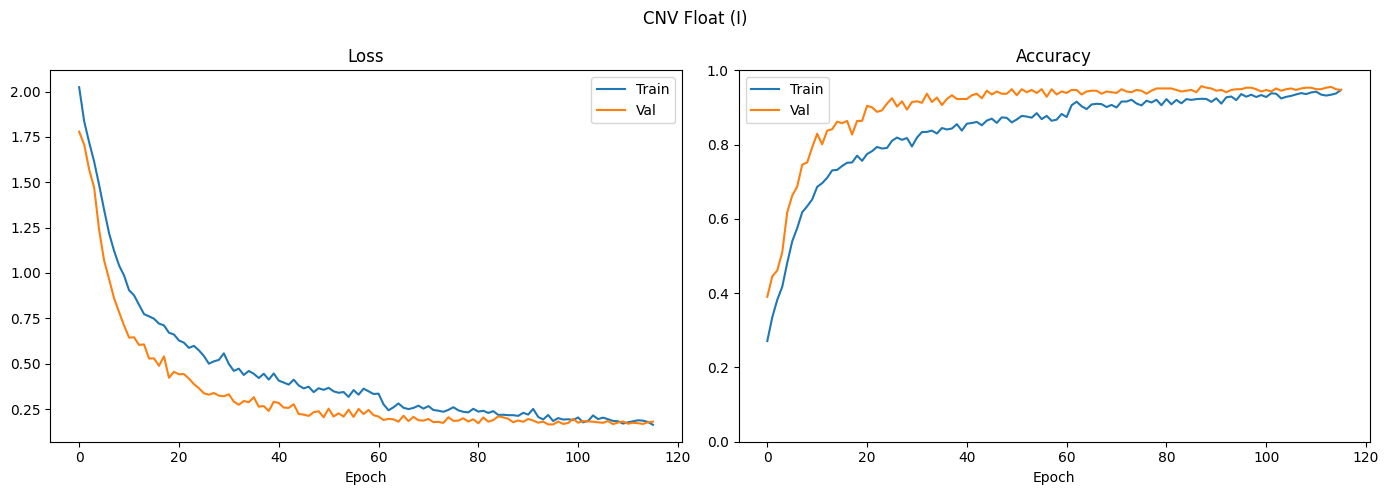

In [10]:
print('═' * 60)
print('  CNV FLOAT BASELINE')
print('═' * 60)
hist_cnv_float = train_model(
    model_cnv_float, f'cnv_float_{USE_CHANNELS}',
    cnv_train_loader, cnv_val_loader, DEVICE,
    epochs=150, lr=1e-3, patience=20, use_scheduler=True)
plot_history(hist_cnv_float, f'CNV Float ({USE_CHANNELS})')

════════════════════════════════════════════════════════════
  CNV QAT W4A4
════════════════════════════════════════════════════════════
Transferring float weights to CNV QAT model...
  Transferred 11/11 parameters.
[cnv_qat_W4A4_I] Training: epochs=120, lr=0.0005, patience=20, sched=cosine
    1/120 tl=0.1598 vl=0.2477 ta=0.942 va=0.937 lr=5.0e-04 [1.8s]
    5/120 tl=0.0999 vl=0.2504 ta=0.969 va=0.929 lr=5.0e-04 [0.9s]
   10/120 tl=0.0662 vl=0.2742 ta=0.979 va=0.933 lr=4.9e-04 [0.9s]
   15/120 tl=0.0565 vl=0.2482 ta=0.979 va=0.945 lr=4.8e-04 [0.9s]
   20/120 tl=0.0460 vl=0.2941 ta=0.987 va=0.931 lr=4.7e-04 [0.9s]
   24/120 tl=0.0457 vl=0.2769 ta=0.985 va=0.941 lr=4.5e-04 [1.3s]
  Early stop at 24.
  Restored best (val_loss=0.1872)
  Saved: 4-bits/trained_models/cnv_qat_W4A4_I.pt


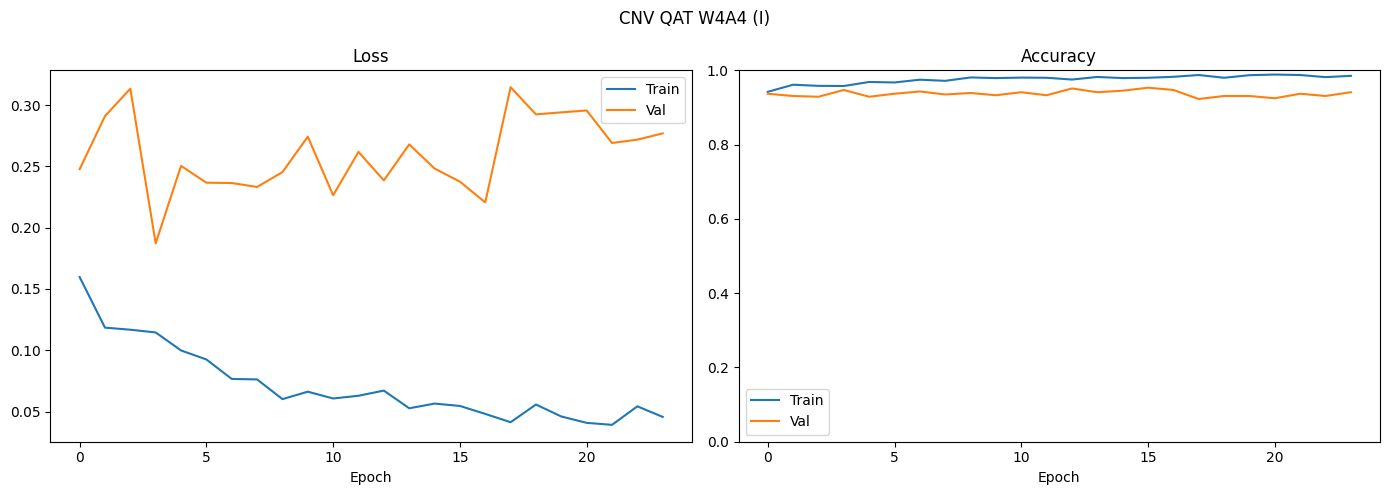

In [11]:
print('═' * 60)
print(f'  CNV QAT W{CNV_WEIGHT_BITS}A{CNV_ACT_BITS}')
print('═' * 60)
ckpt_cnv_qat = MODELS_DIR / f'cnv_qat_W{CNV_WEIGHT_BITS}A{CNV_ACT_BITS}_{USE_CHANNELS}.pt'
if not ckpt_cnv_qat.exists():
    print('Transferring float weights to CNV QAT model...')
    transfer_float_weights(model_cnv_float, model_cnv_quant)
hist_cnv_qat = train_model(
    model_cnv_quant, f'cnv_qat_W{CNV_WEIGHT_BITS}A{CNV_ACT_BITS}_{USE_CHANNELS}',
    cnv_train_loader, cnv_val_loader, DEVICE,
    epochs=120, lr=5e-4, patience=20,
    use_scheduler=False, use_cosine=True)
plot_history(hist_cnv_qat, f'CNV QAT W{CNV_WEIGHT_BITS}A{CNV_ACT_BITS} ({USE_CHANNELS})')

---
## 6. Test-Set Evaluation


  CNV-Float


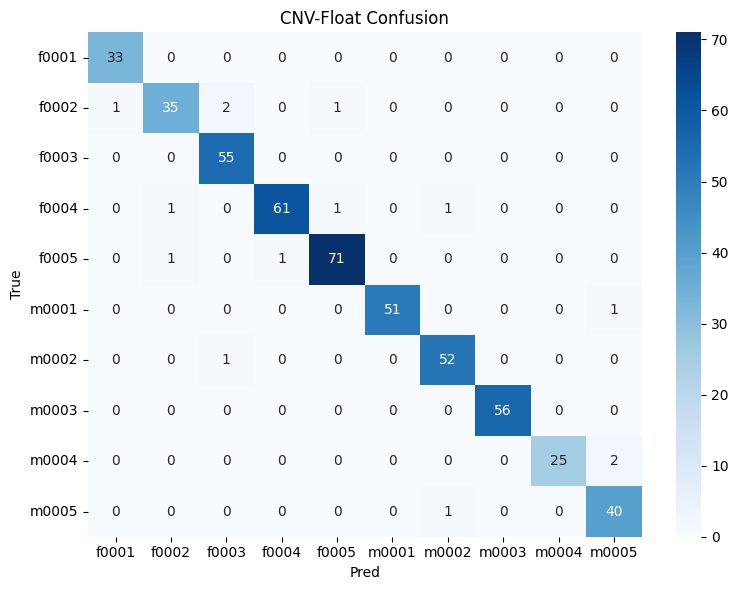

              precision    recall  f1-score   support

       f0001       0.97      1.00      0.99        33
       f0002       0.95      0.90      0.92        39
       f0003       0.95      1.00      0.97        55
       f0004       0.98      0.95      0.97        64
       f0005       0.97      0.97      0.97        73
       m0001       1.00      0.98      0.99        52
       m0002       0.96      0.98      0.97        53
       m0003       1.00      1.00      1.00        56
       m0004       1.00      0.93      0.96        27
       m0005       0.93      0.98      0.95        41

    accuracy                           0.97       493
   macro avg       0.97      0.97      0.97       493
weighted avg       0.97      0.97      0.97       493


  CNV-W4A4


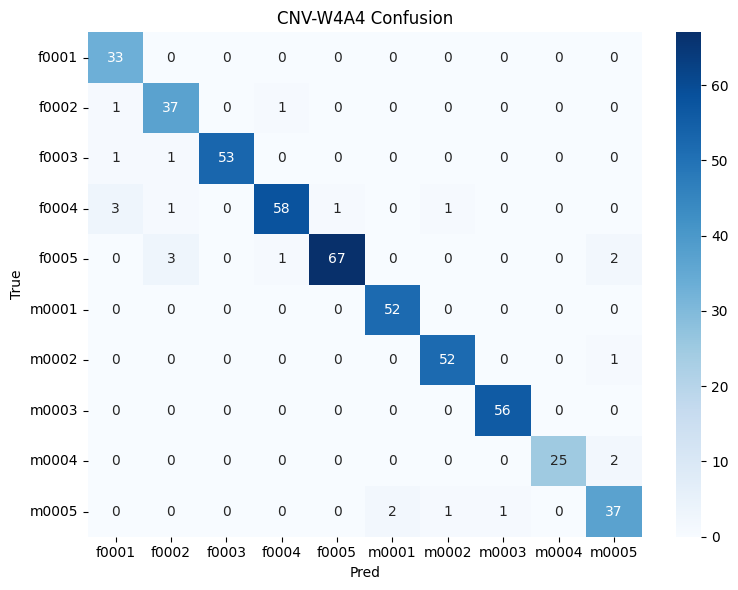

              precision    recall  f1-score   support

       f0001       0.87      1.00      0.93        33
       f0002       0.88      0.95      0.91        39
       f0003       1.00      0.96      0.98        55
       f0004       0.97      0.91      0.94        64
       f0005       0.99      0.92      0.95        73
       m0001       0.96      1.00      0.98        52
       m0002       0.96      0.98      0.97        53
       m0003       0.98      1.00      0.99        56
       m0004       1.00      0.93      0.96        27
       m0005       0.88      0.90      0.89        41

    accuracy                           0.95       493
   macro avg       0.95      0.95      0.95       493
weighted avg       0.96      0.95      0.95       493


╔════════════════════════════════════════════════════════════════════╗
║                   TRAINING & VALIDATION ACCURACY                   ║
╚════════════════════════════════════════════════════════════════════╝
───────────────────────────

In [12]:
config_results = {}
results = {}
eval_configs = []
eval_pairs = []

# Training and Validation evaluation
eval_configs.append(('CNV-Float', model_cnv_float, cnv_train_loader, cnv_val_loader))
eval_configs.append((f'CNV-W{CNV_WEIGHT_BITS}A{CNV_ACT_BITS}', model_cnv_quant, cnv_train_loader, cnv_val_loader))

# Test evaluation for confussion matrix
eval_pairs.append(('CNV-Float', model_cnv_float, cnv_test_loader))
eval_pairs.append((f'CNV-W{CNV_WEIGHT_BITS}A{CNV_ACT_BITS}', model_cnv_quant, cnv_test_loader))

# Generate confusion matrices
for name, model, loader in eval_pairs:
    print(f'\n{"="*50}\n  {name}\n{"="*50}')
    model.to(DEVICE)
    results[name] = full_eval(model, loader, DEVICE, subfolders, f'{name} Confusion')

print('\n' + '╔' + '═' * 68 + '╗')
print('║' + ' TRAINING & VALIDATION ACCURACY '.center(68) + '║')
print('╚' + '═' * 68 + '╝')

crit = nn.CrossEntropyLoss()
for name, model, train_loader, val_loader in eval_configs:
    model.to(DEVICE)
    
    _, train_acc = evaluate(model, train_loader, crit, DEVICE)
    _, val_acc = evaluate(model, val_loader, crit, DEVICE)
    
    results[name] = {'train': train_acc, 'val': val_acc}

print('─' * 70)
print(f'{"Model":<28} {"Training Accuracy":>20} {"Validation Accuracy":>20}')
print('─' * 70)
for n, accs in results.items():
    print(f'  {n:<26} {accs["train"]*100:>18.2f}% {accs["val"]*100:>22.2f}%')
print('─' * 70)

---
## 7. QONNX Export

In [13]:
def export_brevitas_qonnx(model, name, dummy_input):
    """Export Brevitas model to QONNX format for FINN."""
    p = ONNX_DIR / f'{name}.onnx'
    if p.exists():
        print(f'  [{name}] exists')
        return p
    model.eval().cpu()
    export_qonnx(model, dummy_input, str(p))
    onnx.checker.check_model(onnx.load(str(p)))
    print(f'  [{name}] exported: {p}')
    return p

qonnx_paths = {}

dummy_cnv = torch.randn(1, INPUT_CHANNELS, N_MFCC, MFCC_FRAMES)
qonnx_paths['cnv'] = export_brevitas_qonnx(
    model_cnv_quant,
    f'speaker_cnv_W{CNV_WEIGHT_BITS}A{CNV_ACT_BITS}_{USE_CHANNELS}',
    dummy_cnv)

print(f'\nExported: {list(qonnx_paths.keys())}')

  [speaker_cnv_W4A4_I] exported: 4-bits/onnx_exports/speaker_cnv_W4A4_I.onnx

Exported: ['cnv']


## 8. Deployment artifacts for Kria KV260

In [14]:
import struct

def extract_input_scale(model, input_size_or_shape):
    """
    Extract the input QuantIdentity scale and zero_point.

    input_size_or_shape:
        - int  → FC model, flat input of that length
        - tuple (C, H, W) → CNV model, spatial input
    """
    model.eval().cpu()
    with torch.no_grad():
        if isinstance(input_size_or_shape, int):
            dummy = torch.zeros(1, input_size_or_shape)
        else:
            C, H, W = input_size_or_shape
            dummy = torch.zeros(1, C, H, W)
        qt = model.inp_quant(dummy)
        scale = qt.scale.item()
        zp    = qt.zero_point.item()
    return float(scale), float(zp)

def quantize_for_finn(X_float, scale, zero_point, signed=True):
    """Apply the same quantization the Brevitas QuantIdentity applies.
    Returns int8 numpy array (the integer representation the hardware sees)."""
    x_q = np.round(X_float / scale) + zero_point
    if signed:
        return np.clip(x_q, -128, 127).astype(np.int8)
    else:
        return np.clip(x_q, 0, 255).astype(np.uint8)

deploy_meta = {}

scale_cnv, zp_cnv = extract_input_scale(model_cnv_quant, (INPUT_CHANNELS, N_MFCC, MFCC_FRAMES))
print(f'CNV input scale={scale_cnv:.6f}  zero_point={zp_cnv}')

X_test_cnv_sel = select_channels(X_test, USE_CHANNELS)
# NCHW: (N, C, H, W)
X_test_cnv_nchw = X_test_cnv_sel.transpose(0, 3, 1, 2)
X_test_cnv_q = quantize_for_finn(X_test_cnv_nchw, scale_cnv, zp_cnv, signed=True)

cnv_deploy = FINN_BUILD_DIR / 'cnv' / 'deploy_extras'
cnv_deploy.mkdir(parents=True, exist_ok=True)
np.save(cnv_deploy / 'X_test_q.npy',    X_test_cnv_q)
np.save(cnv_deploy / 'y_test.npy',      y_test)
np.save(cnv_deploy / 'input_scale.npy', np.array([scale_cnv, zp_cnv], dtype=np.float32))
with open(cnv_deploy / 'classes.json', 'w') as f:
    json.dump({'classes': subfolders, 'num_classes': NUM_CLASSES,
               'use_channels': USE_CHANNELS, 'n_mfcc': N_MFCC,
               'mfcc_frames': MFCC_FRAMES, 'hop_length': HOP_LENGTH,
               'n_fft': 2048, 'sampling_freq': SAMPLING_FREQ,
               'input_shape_fc': [1, int(FC_INPUT_SIZE)],
               'input_shape_cnv': [1, INPUT_CHANNELS, N_MFCC, MFCC_FRAMES],
               'weight_bits': CNV_WEIGHT_BITS, 'act_bits': CNV_ACT_BITS}, f, indent=2)
deploy_meta['cnv'] = str(cnv_deploy)
print(f'CNV deploy extras → {cnv_deploy}')
print(f'    X_test_q shape : {X_test_cnv_q.shape}  dtype={X_test_cnv_q.dtype}')

print('\nDeployment artifacts saved.')

CNV input scale=0.701747  zero_point=0.0
CNV deploy extras → 4-bits/finn_build/cnv/deploy_extras
    X_test_q shape : (493, 1, 20, 64)  dtype=int8

Deployment artifacts saved.


---
## 9. FINN Synthesis


### Build Configuration

In [15]:
# ─── Source Vitis HLS ─────────────────────────────────────────────────────────
vitis_settings = '/tools/Xilinx/Vitis_HLS/2022.2/settings64.sh'
if os.path.exists(vitis_settings):
    result = subprocess.run(
        ['bash', '-c', f'source {vitis_settings} && env'],
        capture_output=True, text=True)
    for line in result.stdout.splitlines():
        if '=' in line:
            k, _, v = line.partition('=')
            os.environ[k] = v
    print(f'vitis_hls: {subprocess.run(["which","vitis_hls"], capture_output=True, text=True).stdout.strip()}')
else:
    print(f'WARNING: {vitis_settings} not found')

os.environ['VIVADO_PATH'] = '/tools/Xilinx/Vivado/2022.2'
os.environ['HLS_PATH'] = '/tools/Xilinx/Vitis_HLS/2022.2'
os.environ['XILINX_LOCAL_USER_DATA'] = 'no'

vitis_hls: /tools/Xilinx/Vitis_HLS/2022.2/bin/vitis_hls


In [16]:
import finn.builder.build_dataflow as build
import finn.builder.build_dataflow_config as build_cfg
from finn.builder.build_dataflow_config import DataflowBuildConfig, ShellFlowType
from finn.builder.build_dataflow_steps import (
    step_qonnx_to_finn, step_tidy_up, step_streamline, step_convert_to_hw,
    step_create_dataflow_partition, step_specialize_layers,
    step_target_fps_parallelization, step_apply_folding_config,
    step_minimize_bit_width, step_generate_estimate_reports,
    step_hw_codegen, step_hw_ipgen, step_set_fifo_depths,
    step_create_stitched_ip, step_measure_rtlsim_performance,
    step_synthesize_bitfile, step_make_pynq_driver, step_deployment_package
)

# Build steps
BUILD_STEPS = [
    step_qonnx_to_finn,              
    step_tidy_up,                    
    step_streamline,                 
    step_convert_to_hw,              
    step_create_dataflow_partition,  
    step_specialize_layers,          
    step_target_fps_parallelization, 
    step_apply_folding_config,       
    step_minimize_bit_width,         
    step_generate_estimate_reports,  
    step_hw_codegen,                 
    step_hw_ipgen,                   
    step_set_fifo_depths,
    step_create_stitched_ip,         
    step_measure_rtlsim_performance, 
    step_synthesize_bitfile,         
    step_make_pynq_driver,           
    step_deployment_package,         
]
print(f'FINN: {len(BUILD_STEPS)} steps | Build for FPGA part: {FPGA_PART} running @ {1000/CLOCK_NS:.0f} MHz')

FINN: 18 steps | Build for FPGA part: xck26-sfvc784-2LV-c running @ 200 MHz


### Running Synthesis

In [17]:
# ─── Run synthesis ────────────────────────────────────────────────────────────
for tag, onnx_path in qonnx_paths.items():
    bd = FINN_BUILD_DIR / tag
    if (bd/'bitfile').exists() and any((bd/'bitfile').glob('*.bit')):
        print(f'[{tag}] Bitstream exists — skip.')
        continue
    label = tag.upper()
    print(f'\n{"="*60}')
    print(f'  FINN Build: {label} | VIVADO_ZYNQ')
    print(f'{"="*60}\n')
    cfg = DataflowBuildConfig(
        output_dir=str(bd),
        synth_clk_period_ns=CLOCK_NS,
        fpga_part=FPGA_PART,
        target_fps=TARGET_FPS,
        board=BOARD,
        shell_flow_type=ShellFlowType.VIVADO_ZYNQ,
        hls_clk_period_ns=CLOCK_NS,
        rtlsim_batch_size=100,
        large_fifo_mem_style = 'ultra',
        generate_outputs=[
            build_cfg.DataflowOutputType.ESTIMATE_REPORTS,
            build_cfg.DataflowOutputType.STITCHED_IP,
            build_cfg.DataflowOutputType.RTLSIM_PERFORMANCE,
            build_cfg.DataflowOutputType.BITFILE,
            build_cfg.DataflowOutputType.PYNQ_DRIVER,
            build_cfg.DataflowOutputType.DEPLOYMENT_PACKAGE,
        ],
        steps=BUILD_STEPS,
        save_intermediate_models=True,
        folding_config_file=str(BASE_DIR / 'cnv_folding_config.json'),
    )
    t0 = time.time()
    build.build_dataflow_cfg(str(onnx_path), cfg)
    print(f'\n[{tag}] Done in {(time.time()-t0)/60:.1f} min.')


  FINN Build: CNV | VIVADO_ZYNQ

Building dataflow accelerator from 4-bits/onnx_exports/speaker_cnv_W4A4_I.onnx
Intermediate outputs will be generated in /tmp/finn_dev_emanuel-hernandez
Final outputs will be generated in 4-bits/finn_build/cnv
Build log is at 4-bits/finn_build/cnv/build_dataflow.log
Running step: step_qonnx_to_finn [1/18]
Running step: step_tidy_up [2/18]
Running step: step_streamline [3/18]
Running step: step_convert_to_hw [4/18]
Running step: step_create_dataflow_partition [5/18]
Running step: step_specialize_layers [6/18]
Running step: step_target_fps_parallelization [7/18]
Running step: step_apply_folding_config [8/18]
Running step: step_minimize_bit_width [9/18]
Running step: step_generate_estimate_reports [10/18]
Running step: step_hw_codegen [11/18]
Running step: step_hw_ipgen [12/18]
Running step: step_set_fifo_depths [13/18]
Running step: step_create_stitched_ip [14/18]
Running step: step_measure_rtlsim_performance [15/18]
Running step: step_synthesize_bitfile

---
## 10. Post-Synthesis Reports

In [18]:
import re

KV260_RESOURCES = {
    'LUT': 117120, 'FF': 234240, 'BRAM_36K': 144, 'URAM': 64, 'DSP': 1248,
}

def parse_post_synth_resources(build_dir):
    json_path = build_dir / 'report' / 'post_synth_resources.json'
    if not json_path.exists(): return None, None
    with open(json_path) as f: data = json.load(f)
    top = data.get('(top)', {})
    res = {
        'LUT': top.get('LUT', 0), 'SRL': top.get('SRL', 0),
        'FF': top.get('FF', 0), 'BRAM_36K': top.get('BRAM_36K', 0),
        'BRAM_18K': top.get('BRAM_18K', 0), 'URAM': top.get('URAM', 0),
        'DSP': top.get('DSP', 0),
    }
    res['BRAM_36K_equiv'] = res['BRAM_36K'] + res['BRAM_18K'] / 2.0
    return res, str(json_path)

def parse_post_route_timing(build_dir):
    rpt_path = build_dir / 'report' / 'post_route_timing.rpt'
    if not rpt_path.exists(): return None, None
    with open(rpt_path) as f: text = f.read()
    timing = {}
    m = re.search(r'clk_pl_0\s+\{[^}]+\}\s+([\d.]+)\s+([\d.]+)', text)
    if m:
        timing['period_ns'] = float(m.group(1))
        timing['target_freq_MHz'] = float(m.group(2))
    m_wns = re.search(r'Clock\s+WNS\(ns\).*?\n\s*clk_pl_0\s+([-\d.]+)', text, re.DOTALL)
    if m_wns:
        timing['WNS_ns'] = float(m_wns.group(1))
    if 'period_ns' in timing and 'WNS_ns' in timing:
        timing['max_freq_MHz'] = 1000.0 / (timing['period_ns'] - timing['WNS_ns'])
        timing['timing_met'] = timing['WNS_ns'] >= 0
    return timing, str(rpt_path)

# Collect and display
for tag in qonnx_paths:
    bd = FINN_BUILD_DIR / tag
    if not bd.exists():
        print(f'[{tag}] Build dir not found — skipping.')
        continue
    res, res_path = parse_post_synth_resources(bd)
    tim, tim_path = parse_post_route_timing(bd)
    if res is None and tim is None:
        print(f'[{tag}] No reports found.')
        continue
    label = tag.upper()
    print(f'\n╔{"═"*60}╗')
    print(f'║ {label:^58} ║')
    print(f'╚{"═"*60}╝')
    if res:
        print(f'  {"Resource":<22} {"Used":>10} {"Available":>12} {"Util":>10}')
        print(f'  {"─"*56}')
        for rname, rkey, avail_key in [
            ('LUT', 'LUT', 'LUT'), ('FF', 'FF', 'FF'),
            ('BRAM (36K-eq)', 'BRAM_36K_equiv', 'BRAM_36K'),
            ('DSP', 'DSP', 'DSP'), ('URAM', 'URAM', 'URAM')]:
            v = res.get(rkey, 0)
            a = KV260_RESOURCES[avail_key]
            v_str = f'{v:,.0f}' if v == int(v) else f'{v:,.1f}'
            print(f'  {rname:<22} {v_str:>10} {a:>12,} {v/a*100:>8.1f} %')
    if tim:
        print(f'\n  WNS: {tim.get("WNS_ns","?"):.3f} ns  |  Max freq: {tim.get("max_freq_MHz","?"):.1f} MHz  |  Met: {tim.get("timing_met","?")}')


╔════════════════════════════════════════════════════════════╗
║                            CNV                             ║
╚════════════════════════════════════════════════════════════╝
  Resource                     Used    Available       Util
  ────────────────────────────────────────────────────────
  LUT                        12,569      117,120     10.7 %
  FF                         17,281      234,240      7.4 %
  BRAM (36K-eq)                  13          144      9.0 %
  DSP                             3        1,248      0.2 %
  URAM                            5           64      7.8 %

  WNS: 0.661 ns  |  Max freq: 230.5 MHz  |  Met: True


## RTL Simulation Report

In [19]:
# ─── RTL Simulation Performance Report ───────────────────────────────────────
# Reads finn_build_v2/{tag}/report/rtlsim_performance.json produced by step_measure_rtlsim_performance

print('\n' + '═' * 60)
print('  RTL SIMULATION PERFORMANCE REPORT')
print('═' * 60)

for tag in qonnx_paths:
    bd = FINN_BUILD_DIR / tag
    rtlsim_path = bd / 'report' / 'rtlsim_performance.json'

    print(f'\n  ┌─ {tag.upper()} ─────────────────────────────────')

    if not rtlsim_path.exists():
        print(f'  │  ✗ REPORT NOT FOUND: {rtlsim_path}')
        print(f'  │    This means the RTL simulation either:')
        print(f'  │    - deadlocked (never produced output), or')
        print(f'  │    - was skipped because a prior step failed.')
        print(f'  │    Check finn_build_v2/{tag}/build.log for timeout/hang.')
        print(f'  └─────────────────────────────────────────────')
        continue

    with open(rtlsim_path) as f:
        rdata = json.load(f)

    throughput = rdata.get('throughput[images/s]', None)
    runtime_ms = rdata.get('runtime[ms]', None)
    n_samples  = rdata.get('N', None)

    print(f'  │  Samples  : {n_samples}')
    print(f'  │  Throughput: {float(throughput):>12,.1f} images/s' if throughput else '  │  Throughput: N/A')
    print(f'  │  Runtime  : {float(runtime_ms):>12,.1f} ms'        if runtime_ms else '  │  Runtime  : N/A')
    print(f'  │  File     : {rtlsim_path}')
    print(f'  └─────────────────────────────────────────────')

print()


════════════════════════════════════════════════════════════
  RTL SIMULATION PERFORMANCE REPORT
════════════════════════════════════════════════════════════

  ┌─ CNV ─────────────────────────────────
  │  Samples  : 100
  │  Throughput:        168.8 images/s
  │  Runtime  :        592.4 ms
  │  File     : 4-bits/finn_build/cnv/report/rtlsim_performance.json
  └─────────────────────────────────────────────

